In [1]:
import numpy as np
import math
points = np.array([(1,1), (2,1), (3,4), (5,7), (3,3)])
def euclidean(p1, p2):
    return math.sqrt(np.sum((p1 - p2) ** 2))

In [2]:
def cluster_distance(c1, c2, method):
    if method == "single":
        return min(euclidean(p1, p2) for p1 in c1 for p2 in c2)
    elif method == "complete":
        return max(euclidean(p1, p2) for p1 in c1 for p2 in c2)
    elif method == "average":
        distances = [euclidean(p1, p2) for p1 in c1 for p2 in c2]
        return sum(distances) / len(distances)
    elif method == "centroid":
        centroid1 = np.mean(c1, axis=0)
        centroid2 = np.mean(c2, axis=0)
        return euclidean(centroid1, centroid2)
    elif method == "ward":
        merged = np.vstack((c1, c2))
        c1_mean = np.mean(c1, axis=0)
        c2_mean = np.mean(c2, axis=0)
        merged_mean = np.mean(merged, axis=0)
        sse_before = np.sum((c1 - c1_mean)**2) + np.sum((c2 - c2_mean)**2)
        sse_after = np.sum((merged - merged_mean)**2)
        return sse_after - sse_before

In [6]:
def agglomerative(points, method="single"):
    clusters = [[p] for p in points]
    history = []
   
    while len(clusters) > 1:
        min_dist = float("inf")
        to_merge = (None, None)
        for i in range(len(clusters)):
            for j in range(i+1, len(clusters)):
                dist = cluster_distance(clusters[i], clusters[j], method)
                if dist < min_dist:
                    min_dist = dist
                    to_merge = (i, j)
        i, j = to_merge
        new_cluster = clusters[i] + clusters[j]
        history.append((clusters[i], clusters[j], min_dist))
        clusters.pop(j)
        clusters.pop(i)
        clusters.append(new_cluster)
   
    return history

In [7]:
methods = ["single", "complete", "average", "centroid", "ward"]
for m in methods:
    print(f"\n--- {m.capitalize()} linkage ---")
    history = agglomerative(points, method=m)
    for step in history:
        print(f"Merged {step[0]} and {step[1]} at distance {step[2]:.2f}")


--- Single linkage ---
Merged [array([1, 1])] and [array([2, 1])] at distance 1.00
Merged [array([3, 4])] and [array([3, 3])] at distance 1.00
Merged [array([1, 1]), array([2, 1])] and [array([3, 4]), array([3, 3])] at distance 2.24
Merged [array([5, 7])] and [array([1, 1]), array([2, 1]), array([3, 4]), array([3, 3])] at distance 3.61

--- Complete linkage ---
Merged [array([1, 1])] and [array([2, 1])] at distance 1.00
Merged [array([3, 4])] and [array([3, 3])] at distance 1.00
Merged [array([1, 1]), array([2, 1])] and [array([3, 4]), array([3, 3])] at distance 3.61
Merged [array([5, 7])] and [array([1, 1]), array([2, 1]), array([3, 4]), array([3, 3])] at distance 7.21

--- Average linkage ---
Merged [array([1, 1])] and [array([2, 1])] at distance 1.00
Merged [array([3, 4])] and [array([3, 3])] at distance 1.00
Merged [array([1, 1]), array([2, 1])] and [array([3, 4]), array([3, 3])] at distance 2.96
Merged [array([5, 7])] and [array([1, 1]), array([2, 1]), array([3, 4]), array([3, 3]


--- Single linkage ---
[[0.         1.         1.         2.        ]
 [2.         4.         1.         2.        ]
 [5.         6.         2.23606798 4.        ]
 [3.         7.         3.60555128 5.        ]]


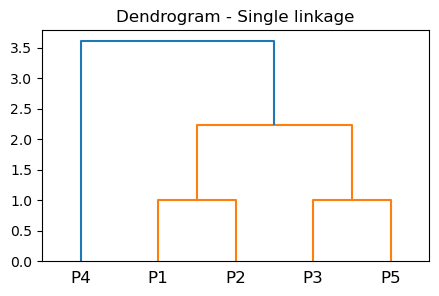


--- Complete linkage ---
[[0.         1.         1.         2.        ]
 [2.         4.         1.         2.        ]
 [5.         6.         3.60555128 4.        ]
 [3.         7.         7.21110255 5.        ]]


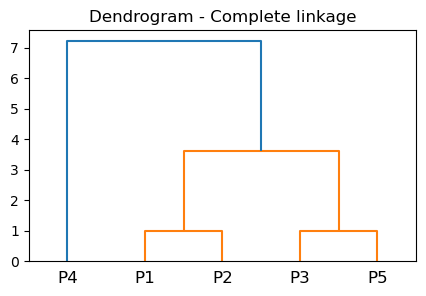


--- Average linkage ---
[[0.         1.         1.         2.        ]
 [2.         4.         1.         2.        ]
 [5.         6.         2.95808101 4.        ]
 [3.         7.         5.49924843 5.        ]]


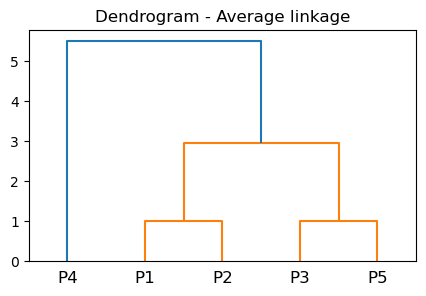


--- Centroid linkage ---
[[0.         1.         1.         2.        ]
 [2.         4.         1.         2.        ]
 [5.         6.         2.91547595 4.        ]
 [3.         7.         5.4886246  5.        ]]


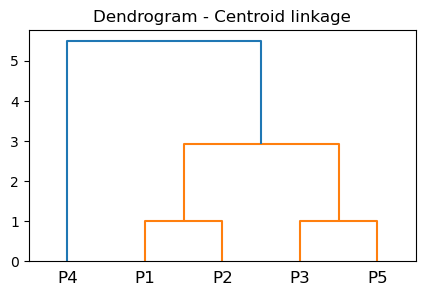


--- Ward linkage ---
[[0.         1.         1.         2.        ]
 [2.         4.         1.         2.        ]
 [5.         6.         4.12310563 4.        ]
 [3.         7.         6.94262198 5.        ]]


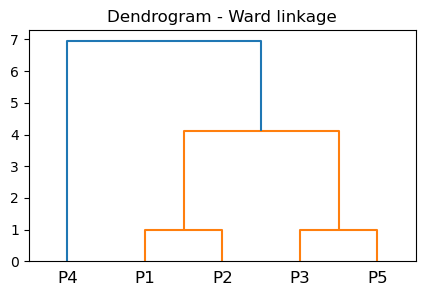

In [8]:

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
points = np.array([(1,1), (2,1), (3,4), (5,7), (3,3)])
methods = ["single", "complete", "average", "centroid", "ward"]
for m in methods:
    print(f"\n--- {m.capitalize()} linkage ---")
    Z = linkage(points, method=m)
    print(Z)
    plt.figure(figsize=(5, 3))
    plt.title(f"Dendrogram - {m.capitalize()} linkage")
    dendrogram(Z, labels=[f"P{i}" for i in range(1,6)])
    plt.show()